In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [ ]:
users = pd.read_csv("/content/drive/MyDrive/data/users.csv")
restaurants = pd.read_csv("/content/drive/MyDrive/data/restaurants.csv")
orders = pd.read_csv("/content/drive/MyDrive/data/orders.csv")
delivery = pd.read_csv("/content/drive/MyDrive/data/delivery.csv")
feedback = pd.read_csv("/content/drive/MyDrive/data/feedback.csv")

In [ ]:
users.head()

,user_id,user_city
0,1,Boston
1,2,Seattle
2,3,San Francisco
3,4,Seattle
4,5,Seattle


In [ ]:
restaurants.head()

,restaurant_id,cuisine,price_range,rating,location
0,1,Mediterranean,$,3.27,University Area
1,2,Mexican,$$$,4.00,City Center
2,3,American,$$$,4.26,Suburbs
3,4,Japanese,$$$,4.52,Suburbs
4,5,Italian,$$$,4.43,Downtown


In [ ]:
orders.head()

,order_id,user_id,restaurant_id,items,order_value,order_time
0,1,307,75,Salad,9.88,2024-02-09 13:00:00
1,2,812,33,Pizza,39.64,2024-01-11 19:00:00
2,3,594,31,Sushi,25.77,2024-01-16 00:00:00
3,4,966,54,Ramen,25.13,2024-02-29 06:00:00
4,5,914,44,Salad,43.73,2024-01-20 03:00:00


In [ ]:
delivery.head()

,order_id,delivery_time,cancelled,refund
0,1,34,1,0
1,2,38,0,0
2,3,37,0,0
3,4,45,0,0
4,5,43,0,0


In [ ]:
feedback.head()

,user_id,restaurant_id,rating,review,reordered
0,307,75,1.0,Growth man maintain dark consumer west foot.,1
1,812,33,4.6,Be Congress one measure.,0
2,594,31,3.4,Free enough her half book shoulder sell.,0
3,966,54,3.7,Member other century summer bed best.,1
4,914,44,4.6,Back difficult determine treatment other vote.,0


In [ ]:
print(users.shape)
print(restaurants.shape)
print(orders.shape)
print(delivery.shape)
print(feedback.shape)

(1000, 2)
(100, 5)
(10000, 6)
(10000, 4)
(10000, 5)


In [ ]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       10000 non-null  int64  
 1   user_id        10000 non-null  int64  
 2   restaurant_id  10000 non-null  int64  
 3   items          10000 non-null  object 
 4   order_value    10000 non-null  float64
 5   order_time     10000 non-null  object 
dtypes: float64(1), int64(3), object(2)
memory usage: 468.9+ KB


#Data Cleaning

In [ ]:
#Convert time column
orders["order_time"] = pd.to_datetime(orders["order_time"])

In [ ]:
#Handling missing Values
orders.isnull().sum()


,0
order_id,0
user_id,0
restaurant_id,0
items,0
order_value,0
order_time,0


In [ ]:
feedback.isnull().sum()


,0
user_id,0
restaurant_id,0
rating,0
review,0
reordered,0


In [ ]:
delivery.isnull().sum()


,0
order_id,0
delivery_time,0
cancelled,0
refund,0


In [ ]:
#Merging tables
data = orders.merge(restaurants, on="restaurant_id")

data = data.merge(
    delivery,
    on="order_id",
    how="left"
)

data = data.merge(
    feedback,
    on=["user_id","restaurant_id"],
    how="left"
)

In [ ]:
data.head()

,order_id,user_id,restaurant_id,items,order_value,order_time,cuisine,price_range,rating_x,location,delivery_time,cancelled,refund,rating_y,review,reordered
0,1,307,75,Salad,9.88,2024-02-09 13:00:00,Mediterranean,$$,3.64,University Area,34,1,0,1.0,Growth man maintain dark consumer west foot.,1
1,2,812,33,Pizza,39.64,2024-01-11 19:00:00,Italian,$,3.97,Suburbs,38,0,0,4.6,Be Congress one measure.,0
2,3,594,31,Sushi,25.77,2024-01-16 00:00:00,Mediterranean,$,3.67,Suburbs,37,0,0,3.4,Free enough her half book shoulder sell.,0
3,4,966,54,Ramen,25.13,2024-02-29 06:00:00,Mediterranean,$,3.81,Suburbs,45,0,0,3.7,Member other century summer bed best.,1
4,5,914,44,Salad,43.73,2024-01-20 03:00:00,Italian,$,3.02,University Area,43,0,0,4.6,Back difficult determine treatment other vote.,0


Feature Engineering

In [ ]:
data["hour"] = data["order_time"].dt.hour
data["day"] = data["order_time"].dt.day_name()

In [ ]:
def meal_time(hour):

    if hour < 11:
        return "Breakfast"

    elif hour < 16:
        return "Lunch"

    else:
        return "Dinner"

data["meal_time"] = data["hour"].apply(meal_time)

In [ ]:
data.head()

,order_id,user_id,restaurant_id,items,order_value,order_time,cuisine,price_range,rating_x,location,delivery_time,cancelled,refund,rating_y,review,reordered,hour,day,meal_time
0,1,307,75,Salad,9.88,2024-02-09 13:00:00,Mediterranean,$$,3.64,University Area,34,1,0,1.0,Growth man maintain dark consumer west foot.,1,13,Friday,Lunch
1,2,812,33,Pizza,39.64,2024-01-11 19:00:00,Italian,$,3.97,Suburbs,38,0,0,4.6,Be Congress one measure.,0,19,Thursday,Dinner
2,3,594,31,Sushi,25.77,2024-01-16 00:00:00,Mediterranean,$,3.67,Suburbs,37,0,0,3.4,Free enough her half book shoulder sell.,0,0,Tuesday,Breakfast
3,4,966,54,Ramen,25.13,2024-02-29 06:00:00,Mediterranean,$,3.81,Suburbs,45,0,0,3.7,Member other century summer bed best.,1,6,Thursday,Breakfast
4,5,914,44,Salad,43.73,2024-01-20 03:00:00,Italian,$,3.02,University Area,43,0,0,4.6,Back difficult determine treatment other vote.,0,3,Saturday,Breakfast


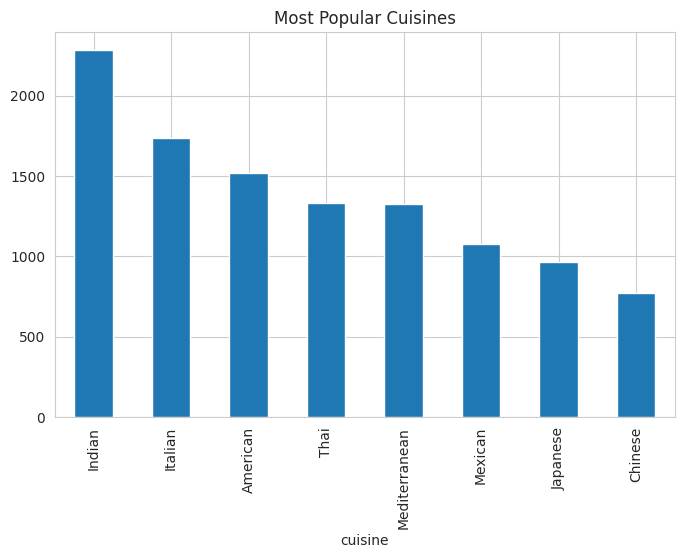

In [ ]:
#EDA
#1.Cusine Popularity
plt.figure(figsize=(8,5))

data["cuisine"].value_counts().plot(kind="bar")

plt.title("Most Popular Cuisines")
plt.show()

#Cusine Vs Time heatmap

Text(0.5, 1.0, 'Cuisine Popularity by Meal Time')

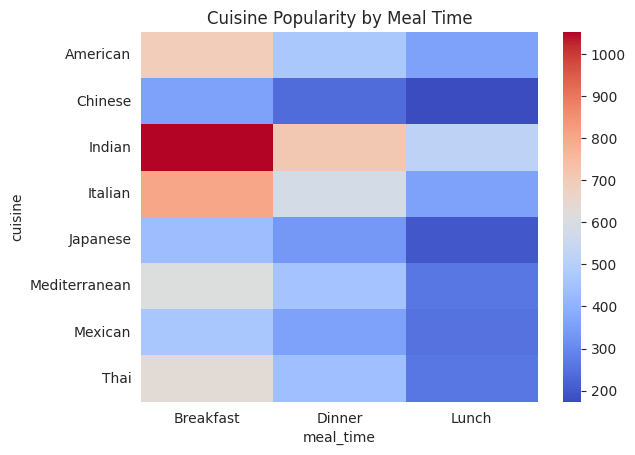

In [ ]:
pivot = pd.pivot_table(
    data,
    values="order_id",
    index="cuisine",
    columns="meal_time",
    aggfunc="count"
)

sns.heatmap(pivot, cmap="coolwarm")
plt.title("Cuisine Popularity by Meal Time")

Text(0.5, 1.0, 'Delivery Time Distribution')

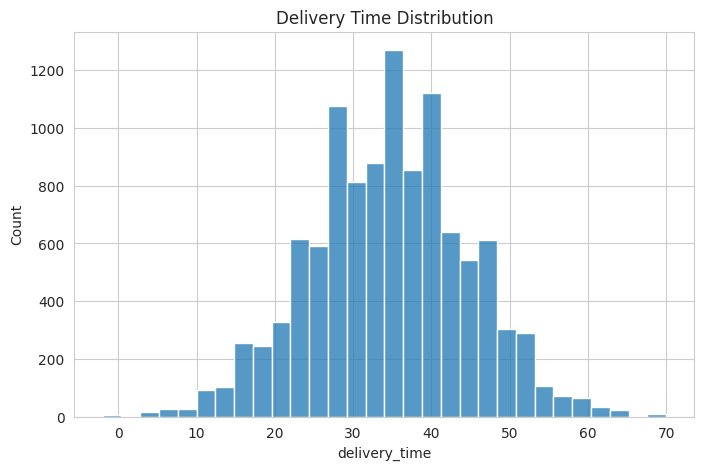

In [ ]:
#Delivery Delay Analysis
plt.figure(figsize=(8,5))

sns.histplot(data["delivery_time"], bins=30)

plt.title("Delivery Time Distribution")

<Axes: xlabel='delivery_time', ylabel='rating_y'>

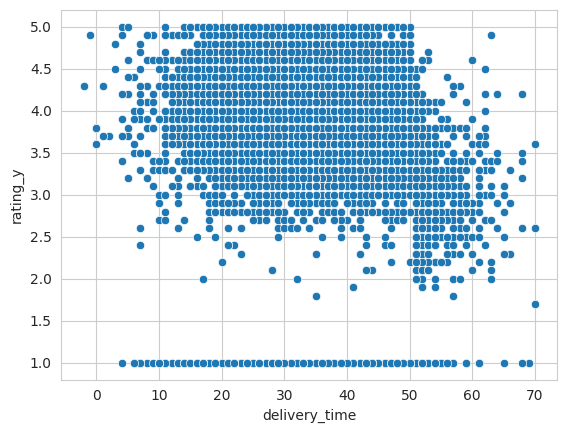

In [ ]:
#rating vs Delivery time
sns.scatterplot(
    x=data["delivery_time"],
    y=data["rating_y"]
)

<Axes: xlabel='cuisine'>

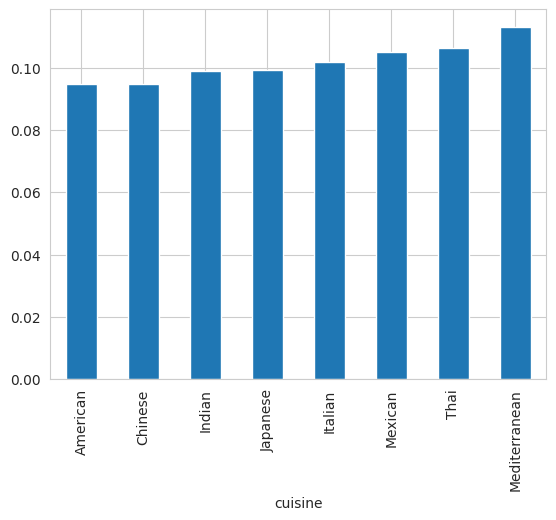

In [ ]:
#cancellation Analysis
cancel_rate = data.groupby("cuisine")["cancelled"].mean()

cancel_rate.sort_values().plot(kind="bar")

<Axes: >

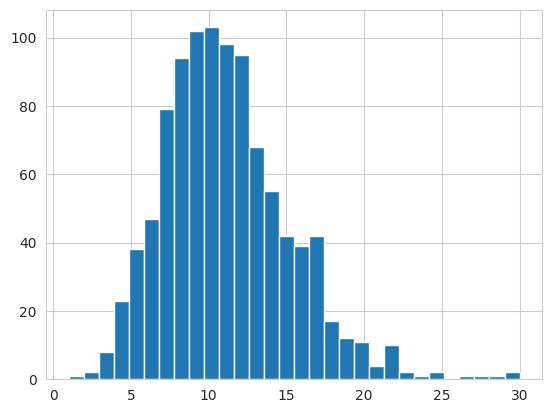

In [ ]:
#Repeat order behaviour
repeat_users = data.groupby("user_id")["order_id"].count()

repeat_users.hist(bins=30)

In [ ]:
#user segmentation
user_features = data.groupby("user_id").agg({
    "order_value":"mean",
    "order_id":"count"
})

user_features.columns = ["avg_spend","order_count"]

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)

user_features["segment"] = kmeans.fit_predict(user_features)